### Importing necessary modules

In [2]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                                     # type: ignore
import tensorflow as tf                                                                 # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (5, 5)
from joblib import dump, load                                                           # type: ignore
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

### Importing dataset

In [7]:
data_part_1 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part1-5nearest-dakar-with-storm-size.csv", index_col=False)
data_part_2 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part2-5nearest-dakar-with-storm-size.csv", index_col=False)
data_part_3 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part3-5nearest-dakar-with-storm-size.csv", index_col=False)
data_part_4 = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-train-part4-5nearest-dakar-with-storm-size.csv", index_col=False)
test_data = pd.read_csv("/home/mendrika/mendrika-phd/data/nflics/Nearest-5/full-data-test-5nearest-dakar-with-storm-size.csv", index_col=False)

#### combining dataset and doing some exploratory analysis

In [9]:
data = pd.concat([data_part_1, data_part_2, data_part_3, data_part_4])

In [10]:
data = data.dropna()
test_data = test_data.dropna()

In [12]:
minute_0 = "00"

In [13]:
query = f"`minute`=={nflics.format(minute_0)}"
test_data = test_data.query(query).reset_index(drop=True)

In [14]:
test_data

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_Dakar
0,2020,6,1,0,0,11.32,-16.08,10.11,-15.77,11.37,...,350,26525,0.0,0.0,121.46,123.66,167.44,999999.00,999999.00,0.0
1,2020,6,1,1,0,10.38,-16.08,10.11,-17.12,10.65,...,4175,4550,0.0,0.0,153.63,155.98,161.00,999999.00,999999.00,0.0
2,2020,6,1,2,0,10.56,-16.35,10.29,-17.48,-9999.00,...,1675,0,0.0,0.0,147.49,155.46,999999.00,999999.00,999999.00,0.0
3,2020,6,1,17,0,12.13,-12.53,11.68,-13.30,-9999.00,...,19125,0,0.0,0.0,169.62,183.48,999999.00,999999.00,999999.00,0.0
4,2020,6,1,18,0,12.67,-12.94,11.64,-13.61,11.86,...,6175,3400,0.0,0.0,162.37,163.29,181.16,999999.00,999999.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4446,2022,9,30,18,0,16.13,-11.28,11.46,-12.27,-9999.00,...,23175,0,0.0,0.0,203.03,219.26,999999.00,999999.00,999999.00,0.0
4447,2022,9,30,19,0,16.76,-12.53,11.64,-12.49,11.77,...,10100,6100,2350.0,9100.0,187.24,193.05,208.22,211.18,214.90,0.0
4448,2022,9,30,20,0,11.59,-11.82,11.28,-12.44,11.77,...,10525,2550,19725.0,3550.0,185.30,195.43,201.06,201.23,213.71,0.0
4449,2022,9,30,21,0,11.37,-10.65,16.76,-12.00,15.86,...,8975,2600,0.0,0.0,188.96,203.54,253.12,999999.00,999999.00,0.0


In [1714]:
pcX0 = pd.read_csv(f"/home/mendrika/mendrika-phd/data/nflics/pcX0/pcX0-full.csv", index_col=None)
to_keep = pcX0["index"].values
to_drop = [i for i in range(len(test_data)) if i not in to_keep]

In [1715]:
test_data = test_data.drop(index=to_drop)

#### Choosing field to include in the data

In [1716]:
# Presence or absence of convection in Dakar at time t+1
target_index = "Cb_Dakar"

# Input at time t
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features + target_index
field = field.split(',')
data = data[field]

### Exploratory data analysis

In [1717]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [1718]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [1719]:
def correct_coord(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if "lat" in key and i == -9999:
                transformed.append(14)
            elif "lon" in key and i == -9999:
                transformed.append(-5)
            else:
                transformed.append(i)
        df_copy[key] = transformed
    return df_copy

In [1720]:
def correct_distance(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i == 999999:
                transformed.append(430)
            else:
                transformed.append(i)
        df_copy[key] = transformed
    return df_copy

In [1721]:
data = correct_coord(data, location.split(',')[:-1])
data = correct_distance(data, distance.split(',')[:-1])
test_data = correct_coord(test_data, location.split(',')[:-1])
test_data = correct_distance(test_data, distance.split(',')[:-1])

In [1722]:
original_test_data = test_data.copy()

In [1723]:
to_scale = wavelet_power + storm_size + distance

In [1724]:
transform = True
if transform:
    data = log_transform(data, to_scale.split(',')[:-1])    
    data = sqrt_transform(data, t0.split(',')[:-1])
    test_data = log_transform(test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(test_data, t0.split(',')[:-1])

#### splitting the data  into training and testing before oversampling the training set

In [1725]:
x_test = test_data.drop([target_index], axis=1)
y_test = test_data[target_index]

In [1726]:
model = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/best_model_new_format_Dakar_nearest5_corrected.keras")

In [1727]:
scaler = load('std_scaler_best_model_new_format_Dakar_nearest5_corrected.bin')

#### Normalising the features

In [1728]:
x_test_std = scaler.transform(x_test)

### Model prediction

In [1729]:
y_hat_model = model.predict(x_test_std)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [1730]:
bs_model = brier_score_loss(y_test, y_hat_model)
print(f"Model BS: {bs_model:.4f}")

Model BS: 0.0464


### Unconditional probability

In [15]:
pc = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/unconditional-probability/dataset-pc-31.csv")

In [1732]:
Cb_Dakar_unc = []
for i in range(len(original_test_data)):
    minute = original_test_data["minute"].values[i]    
    hour = original_test_data["hour"].values[i] + 1
    if hour != 24:    
        index_hour = pc["hour"].values == hour
    else:
        index_hour = pc["hour"].values == 0
    index_minute = pc["minute"].values == minute
    index = index_hour * index_minute
    Cb_Dakar_unc.append(pc["probability"].values[index])
Cb_Dakar_unc = np.array(Cb_Dakar_unc)

In [1733]:
bs_ref_unc = brier_score_loss(y_test, Cb_Dakar_unc)
print(f"BS climatology: {bs_ref_unc:.4f}")

BS climatology: 0.0828


In [1734]:
bss_clim = 1 - (bs_model/bs_ref_unc)
print(f"BSS climatology: {bss_clim:.2f}")

BSS climatology: 0.44


### Conditional probability

In [1735]:
cond_prob = pcX0["pcX0"].values

In [1736]:
bs_ref_cond = brier_score_loss(y_test, cond_prob)
print(f"BS NFLICS: {bs_ref_cond:.4f}")

BS NFLICS: 0.0897


In [1737]:
bss_nflics = 1 - (bs_model/bs_ref_cond)
print(f"BSS NFLICS: {bss_nflics:.2f}")

BSS NFLICS: 0.48


### ROC

In [1738]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)  
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,105])
  ax = plt.gca()
  ax.set_aspect('equal')
  plt.tight_layout()
  plt.legend(loc='lower right');
  plt.savefig(f"/home/mendrika/mendrika-phd/codes/nflics/output/SM2024-05-13/roc-no-resampling-case-study={hour_0}{minute_0}.png")

In [1739]:
auc_model = roc_auc_score(y_test, y_hat_model)
auc_unc = roc_auc_score(y_test, Cb_Dakar_unc)
auc_cond = roc_auc_score(y_test, cond_prob)

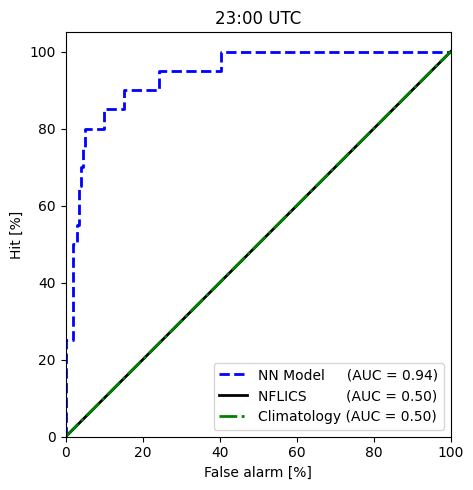

In [1740]:
plot_roc(f"NN Model     (AUC = {auc_model:.2f})", y_test, y_hat_model, color="blue", linestyle='--')
plot_roc(f"NFLICS         (AUC = {auc_cond:.2f})", y_test, cond_prob, color="black", linestyle='-')
plot_roc(f"Climatology (AUC = {auc_unc:.2f})", y_test, Cb_Dakar_unc, color="green", linestyle='-.')

### Confusion matrix

In [1741]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title(f"{hour_0}:{minute_0} UTC")
    plt.tight_layout()
    plt.savefig(f"/home/mendrika/mendrika-phd/codes/nflics/output/SM2024-05-13/cm-no-resampling-case-study={hour_0}{minute_0}.png")
    plt.show()

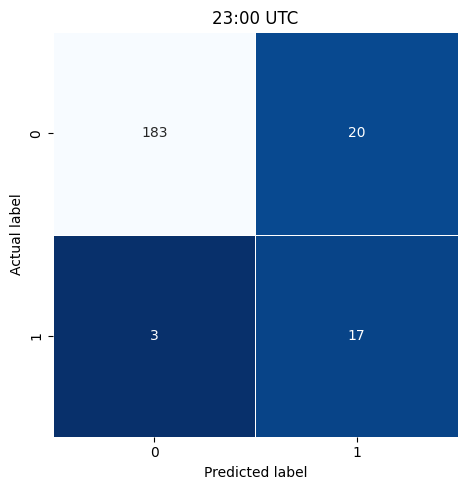

In [1742]:
plot_cm(y_test, y_hat_model, 0.1)

### Reliability curve

In [1743]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

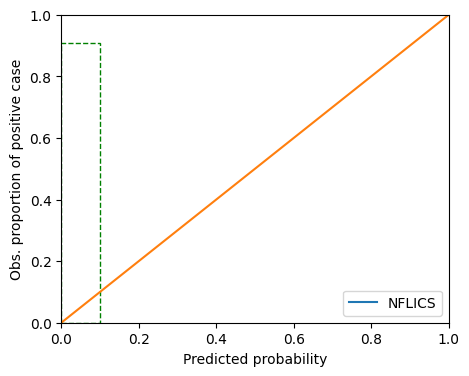

In [1744]:
#prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, cond_prob.flatten(), bin_size=0.1, count_pred_per_bin=10)
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, cond_prob.flatten(), bin_size=0.1, count_pred_per_bin=1)

plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"NFLICS")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend()
plt.show()

In [1745]:
with open("/home/mendrika/mendrika-phd/codes/nflics/output/SM2024-05-13/different-lead-times.csv", "+a") as f:
    f.write(f"{nflics.format(hour_0)},{bss_clim},{bss_nflics}\n")

In [1746]:
lead_times = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/output/SM2024-05-13/different-lead-times.csv")

In [1747]:
t0 = [f"{nflics.date_format(i)}:00" for i in lead_times['t0']]

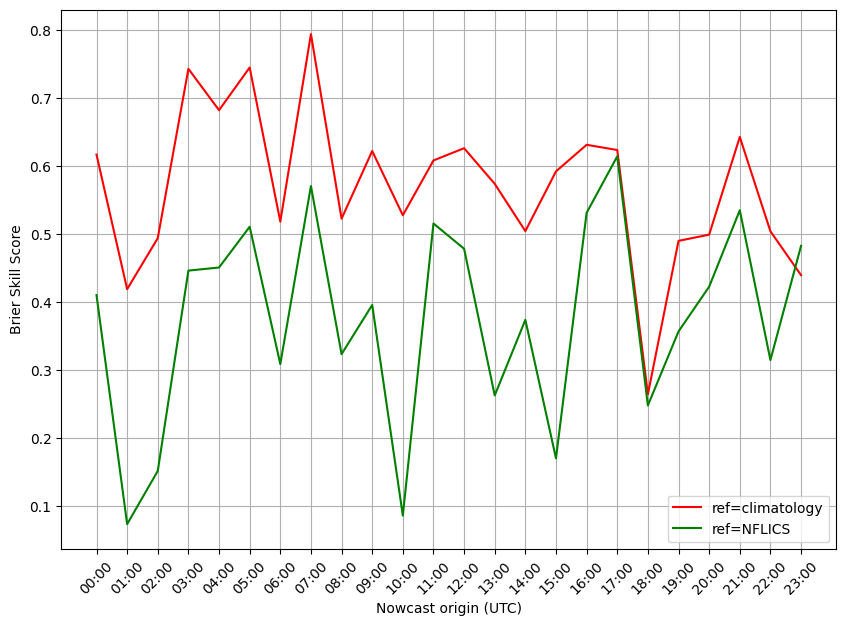

In [1753]:
plt.plot(t0, lead_times["bss_clim"], label="ref=climatology", color="red")
plt.plot(t0, lead_times["bss_nflics"], label="ref=NFLICS", color="green")
plt.xticks(rotation=45)
plt.ylabel("Brier Skill Score")
plt.xlabel("Nowcast origin (UTC)")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()